<a href="https://colab.research.google.com/github/Tejaswini-AnalyticsExpert/Data-Cleaning-Preprocessing/blob/main/Price%20Elasticity%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                            OLS Regression Results                            
Dep. Variable:            ln_quantity   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     118.4
Date:                Fri, 08 May 2026   Prob (F-statistic):           4.03e-27
Time:                        14:30:38   Log-Likelihood:                -3784.7
No. Observations:                3289   AIC:                             7573.
Df Residuals:                    3287   BIC:                             7586.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0198      0.221     22.691      0.0

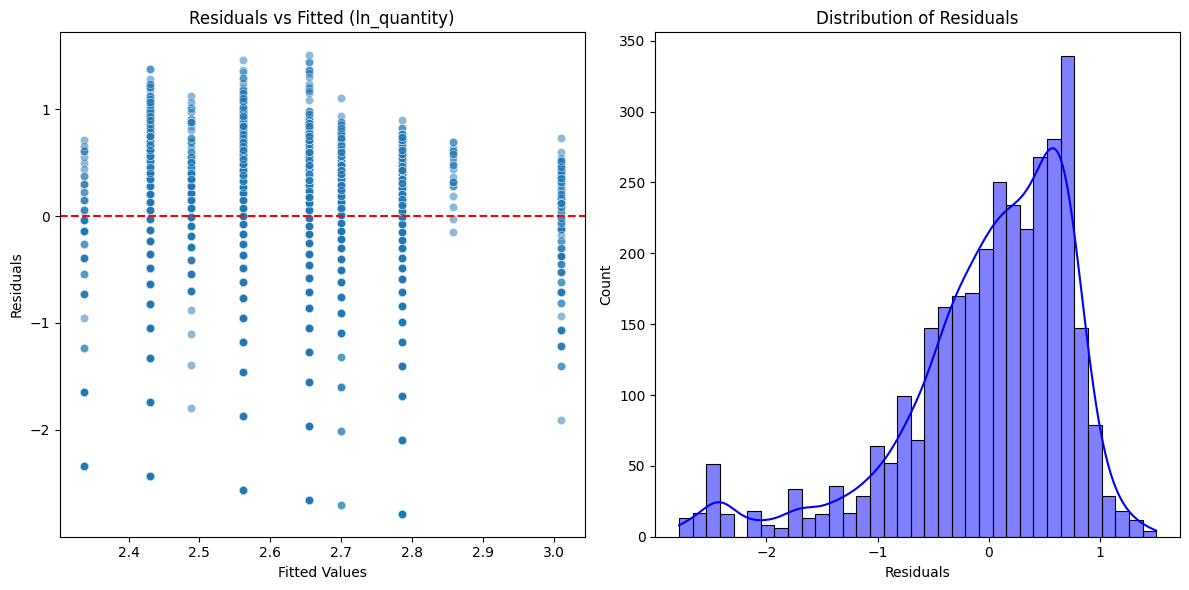

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# 1. Load the dataset
# Ensure the file 'Cleaned_Fitness_Data_2018.csv' is in the working directory
df = pd.read_csv('Cleaned_Fitness_Data_2018.csv')

# 2. Data Preparation for Modeling
# Filter out any non-positive values to ensure log transformation is valid
df = df[(df['Price (INR)'] > 0) & (df['Number Booked'] > 0)].copy()

# Create logarithmic features for the Log-Log model
# Formula: ln(Quantity) = intercept + beta * ln(Price)
df['ln_price'] = np.log(df['Price (INR)'])
df['ln_quantity'] = np.log(df['Number Booked'])

# 3. Build the Price Elasticity Model
# Independent variable (X) and Dependent variable (y)
X = df[['ln_price']]
X = sm.add_constant(X)  # Adds an intercept (alpha) to the model
y = df['ln_quantity']

# Fit the OLS (Ordinary Least Squares) regression
model = sm.OLS(y, X).fit()

# Display the regression results summary
print(model.summary())

# 4. Validate the Model
# Generate predictions
df['predictions'] = model.predict(X)
df['residuals'] = model.resid

# Calculate Metrics
mse = mean_squared_error(y, df['predictions'])
r_squared = model.rsquared

print(f"\nModel Validation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Price Elasticity Coefficient: {model.params['ln_price']:.4f}")

# 5. Visual Validation (Residual Plots)
plt.figure(figsize=(12, 6))

# Plot 1: Residuals vs. Fitted Values
# Used to check for homoscedasticity and non-linear patterns
plt.subplot(1, 2, 1)
sns.scatterplot(x='predictions', y='residuals', data=df, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted (ln_quantity)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

# Plot 2: Distribution of Residuals
# Used to check for normality of error terms
plt.subplot(1, 2, 2)
sns.histplot(df['residuals'], kde=True, color='blue')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')

plt.tight_layout()
plt.savefig('price_elasticity_validation.png')
plt.show()

# 6. Export Results
# Save the final data with predictions for further analysis
df.to_csv('Price_Elasticity_Predictions.csv', index=False)